In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded=files.upload()

Saving heart.csv to heart.csv


In [3]:
df=pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
df.size

14350

In [7]:
df.shape

(1025, 14)

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [12]:
# which age is having highest heart dises
df.groupby('age')['target'].sum().sort_values(ascending=False).head(10)

,target
age,
54,32
51,29
41,29
52,28
44,26
58,24
42,22
57,21
45,19


In [13]:
# how many people are having disies
df['target'].value_counts()

,count
target,
1,526
0,499


In [14]:
#  percentage of how many people are having disies
df['target'].value_counts(normalize=True)

,proportion
target,
1,0.513171
0,0.486829


In [15]:
# what is gender distribution
df['sex'].value_counts(normalize=True)

,proportion
sex,
1,0.69561
0,0.30439


In [16]:
# min and max age
df['age'].min()


29

In [17]:
df['age'].max()

77

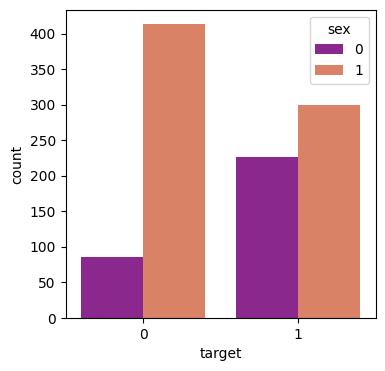

In [18]:
# graphs
# target based on sex
plt.figure(figsize=(4,4))
sns.countplot(x='target',hue='sex',data=df,palette='plasma')
plt.show()

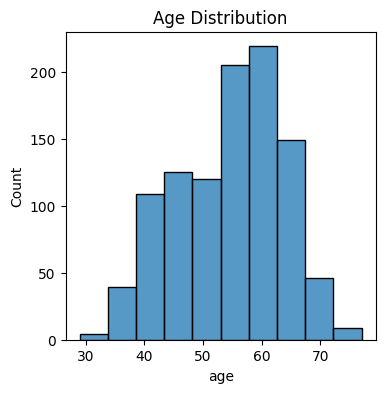

In [19]:
# age distribution
plt.figure(figsize=(4,4))
sns.histplot(df['age'],bins=10)
plt.title('Age Distribution')
plt.show()

In [20]:
# model implementation

# target sepration

x=df.drop(columns='target',axis=1)
y=df['target']

In [21]:
x.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

In [22]:
y.name

'target'

In [23]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
x.shape

(1025, 13)

In [25]:
x_train.shape

(820, 13)

In [26]:
x_test.shape

(205, 13)

In [27]:
y_train.shape

(820,)

In [28]:
y_test.shape

(205,)

In [29]:
# scaling-preprocessing

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [30]:
# LogisticRegression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [31]:
# prediction
y_pread_train = model.predict(x_train_scaled)
y_pread_test = model.predict(x_test_scaled)

In [32]:
# score
model.score(x_train_scaled,y_train)

0.8463414634146341

In [33]:
model.score(x_test_scaled,y_test)

0.8097560975609757

In [34]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pread_test)
cm

array([[70, 30],
       [ 9, 96]])

In [35]:
# classification report
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pread_test)
print(cr)

              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



In [36]:
# implementing another model Decision tree

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
# prediction

y_pred_train_dt =dt_model.predict(x_train)
y_pred_test_dt =dt_model.predict(x_test)

In [38]:
# evaulation-accuracy

from sklearn.metrics import accuracy_score
print('training_accuracy:',accuracy_score(y_train,y_pred_train_dt))
print('Testing_accuracy:',accuracy_score(y_test,y_pred_test_dt))

training_accuracy: 1.0
Testing_accuracy: 0.9853658536585366


In [39]:
# confusion matrix
print("testing confusion matrix")
print(confusion_matrix(y_test,y_pred_test_dt))

testing confusion matrix
[[100   0]
 [  3 102]]


In [40]:
# classification report
print('classification report')
print(classification_report(y_test,y_pred_test_dt))

classification report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

